# Vox Deorum Analysis: Strategist Comparison

This notebook analyzes game results comparing different strategist conditions (excluding none-strategist).

In [11]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import utility functions and CONDITION_MAPPING from the plot-utilities module
from plot_utilities import (
    load_panel_data,
    setup_notebook_display,
    plot_bar_chart,
    plot_grouped_bar_chart,
    plot_distribution_histograms,
    plot_strategy_radar_charts
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(10, 6))

# Load panel data using the unified function
panel_df = load_panel_data('../panel_data.csv', condition_exclude=["observe-vanilla-standard"])
panel_df.head()

✓ Loaded panel data: 2248 rows
✓ Filters applied: condition_exclude=['observe-vanilla-standard']
✓ Unique conditions: 13
✓ Unique player types: 15

Player Type Distribution:
  Vanilla: 730 rows (32.5%)
  GLM-4.7-Simple: 180 rows (8.0%)
  GLM-4.7-Briefed: 180 rows (8.0%)
  GPT-OSS-120B-Simple: 153 rows (6.8%)
  GPT-OSS-120B-Briefed: 153 rows (6.8%)
  Kimi-K2.5-Simple: 144 rows (6.4%)
  Kimi-K2.5-Briefed: 144 rows (6.4%)
  Deepseek-3.2-Briefed: 116 rows (5.2%)
  Deepseek-3.2-Simple: 116 rows (5.2%)
  Minimax-M2.5-Simple: 91 rows (4.0%)
  Minimax-M2.5-Briefed: 91 rows (4.0%)
  Qwen-3.5-Briefed: 47 rows (2.1%)
  Qwen-3.5-Simple: 47 rows (2.1%)
  Sonnet-4.5-Briefed: 28 rows (1.2%)
  Sonnet-4.5-Simple: 28 rows (1.2%)

Condition Distribution:
  2026-deepseek-v-kimi2-v-glm-standard: 664 rows (29.5%)
  2026-oss-v-glm-standard: 528 rows (23.5%)
  2026-oss-v-qwen-v-minimax-standard: 256 rows (11.4%)
  2026-deepseek-v-kimi2-v-minimax-standard: 160 rows (7.1%)
  2026-qwen-v-kimi2-v-minimax-standard

,experiment,game_id,turn,map_type,map_size,difficulty,game_speed,victory_type,victory_player_id,player_id,civilization,score,score_rank,score_ratio,survival_turn,is_winner,input_tokens,reasoning_tokens,output_tokens,strategy_changes,persona_changes,research_changes,policy_changes,nuke,use_nuke,domination_ratio,culture_ratio,diplomatic_ratio,science_ratio,tradition,authority,progress,fealty,statecraft,artistry,industry,imperialism,rationalism,freedom,autocracy,order,condition,player_type
0,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,0,Polynesia,1543,7,0.3550,415,0,0.0,0.0,0.0,191,1,0,0,NaN,NaN,0.3614,0.1205,0.2530,0.2651,NaN,NaN,18.0,NaN,147.0,NaN,NaN,243.0,NaN,NaN,NaN,326.0,2026-deepseek-v-kimi-v-glm-standard,Vanilla
1,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,1,Austria,2643,3,0.6080,415,0,0.0,0.0,0.0,220,1,0,0,50.0,50.0,0.0000,0.0240,0.5288,0.4471,NaN,NaN,17.0,132.0,NaN,NaN,224.0,NaN,NaN,318.0,NaN,NaN,2026-deepseek-v-kimi-v-glm-standard,Vanilla
2,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,2,Babylon,1402,8,0.3225,415,0,13700445.0,1213318.0,230753.0,251,65,65,47,NaN,NaN,0.0000,0.1226,0.0120,0.8654,18.0,NaN,28.0,211.0,NaN,257.0,300.0,346.0,279.0,NaN,NaN,363.0,2026-deepseek-v-kimi-v-glm-standard,Kimi-K2.5-Simple
3,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,3,Portugal,4196,2,0.9653,415,1,29105306.0,1695836.0,2678364.0,304,75,91,76,40.0,40.0,0.0000,0.0120,0.9760,0.0120,113.0,NaN,16.0,NaN,126.0,NaN,237.0,NaN,225.0,NaN,NaN,290.0,2026-deepseek-v-kimi-v-glm-standard,Kimi-K2.5-Briefed
4,2026-deepseek-v-kimi-v-glm-standard,085cfce3-75ee-4459-b7b0-c49c9a27f651,415,Vox_Deorum,Standard,Prince,Standard,Science,3,4,Mongolia,2466,4,0.5673,415,0,14763017.0,811214.0,260286.0,214,99,94,57,100.0,100.0,1.0000,0.0000,0.0000,0.0000,200.0,16.0,126.0,220.0,259.0,178.0,366.0,296.0,346.0,NaN,366.0,NaN,2026-deepseek-v-kimi-v-glm-standard,GLM-4.7-Simple


## 1. Win Rate of Each Player by Condition

Comparing win rates for each player (0-3) between none-strategist and simple-strategist conditions.

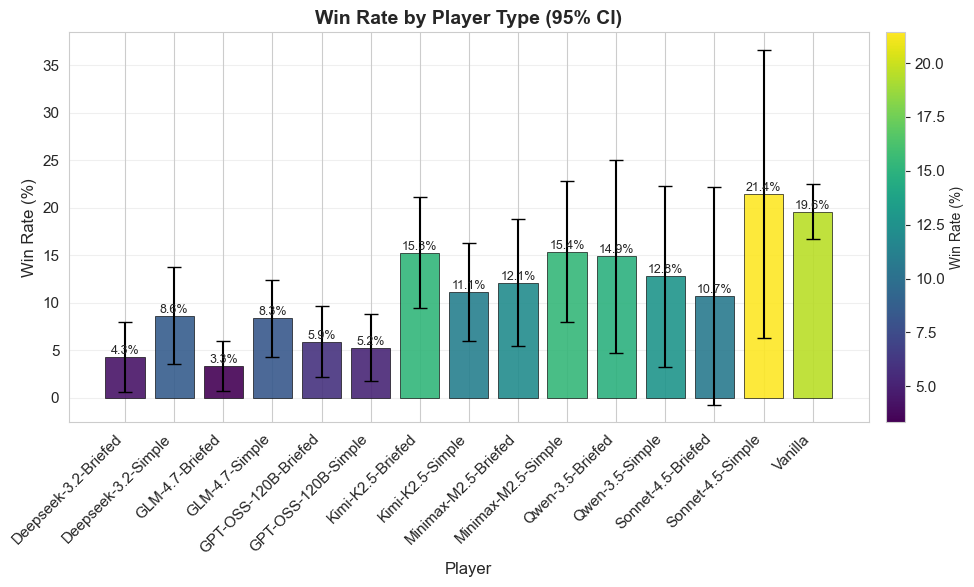

,is_winner=1
Deepseek-3.2-Briefed,5/116 (4.3%)
Deepseek-3.2-Simple,10/116 (8.6%)
GLM-4.7-Briefed,6/180 (3.3%)
GLM-4.7-Simple,15/180 (8.3%)
GPT-OSS-120B-Briefed,9/153 (5.9%)
GPT-OSS-120B-Simple,8/153 (5.2%)
Kimi-K2.5-Briefed,22/144 (15.3%)
Kimi-K2.5-Simple,16/144 (11.1%)
Minimax-M2.5-Briefed,11/91 (12.1%)
Minimax-M2.5-Simple,14/91 (15.4%)


In [12]:
# Create the chart and print summary  
plot_bar_chart(
    panel_df,
    value_col='is_winner',
    category_col='player_type',
    xlabel='Player',
    ylabel='Win Rate (%)',
    title='Win Rate by Player Type',
    use_percentage=True,
    show_error_bars=True
)

## 2. Victory Type Distribution by Condition

Analyzing the types of victories (Cultural, Diplomatic, Domination, Science, Time) across conditions.

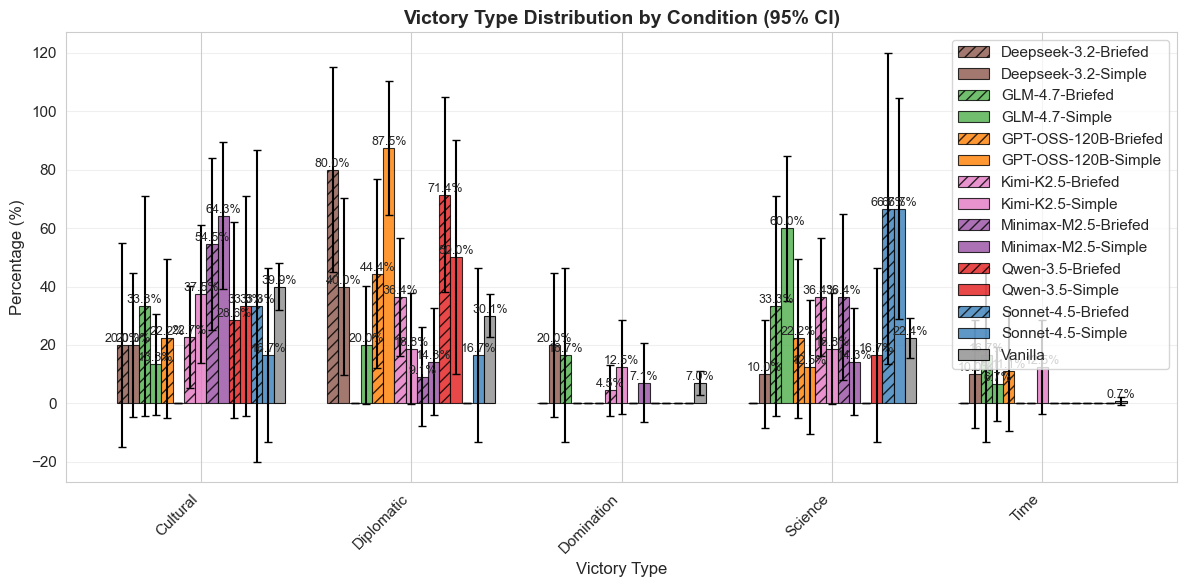

victory_type,Cultural,Diplomatic,Domination,Science,Time
Deepseek-3.2-Briefed,1 (20.0%),4 (80.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Deepseek-3.2-Simple,2 (20.0%),4 (40.0%),2 (20.0%),1 (10.0%),1 (10.0%)
GLM-4.7-Briefed,2 (33.3%),0 (0.0%),1 (16.7%),2 (33.3%),1 (16.7%)
GLM-4.7-Simple,2 (13.3%),3 (20.0%),0 (0.0%),9 (60.0%),1 (6.7%)
GPT-OSS-120B-Briefed,2 (22.2%),4 (44.4%),0 (0.0%),2 (22.2%),1 (11.1%)
GPT-OSS-120B-Simple,0 (0.0%),7 (87.5%),0 (0.0%),1 (12.5%),0 (0.0%)
Kimi-K2.5-Briefed,5 (22.7%),8 (36.4%),1 (4.5%),8 (36.4%),0 (0.0%)
Kimi-K2.5-Simple,6 (37.5%),3 (18.8%),2 (12.5%),3 (18.8%),2 (12.5%)
Minimax-M2.5-Briefed,6 (54.5%),1 (9.1%),0 (0.0%),4 (36.4%),0 (0.0%)
Minimax-M2.5-Simple,9 (64.3%),2 (14.3%),1 (7.1%),2 (14.3%),0 (0.0%)


In [13]:
# Victory type distribution
plot_grouped_bar_chart(
    panel_df[panel_df["is_winner"] == 1],
    value_col=None,  # Not used when use_percentage=True
    category_col='victory_type',
    xlabel='Victory Type',
    ylabel='Percentage (%)',
    title='Victory Type Distribution by Condition',
    use_percentage=True,
    show_error_bars=True,
    rotation=45
)

## 3. Choice of Ideology

C:\Users\John Chen\AppData\Local\Temp\ipykernel_691688\1159868436.py:5: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin(axis=1)


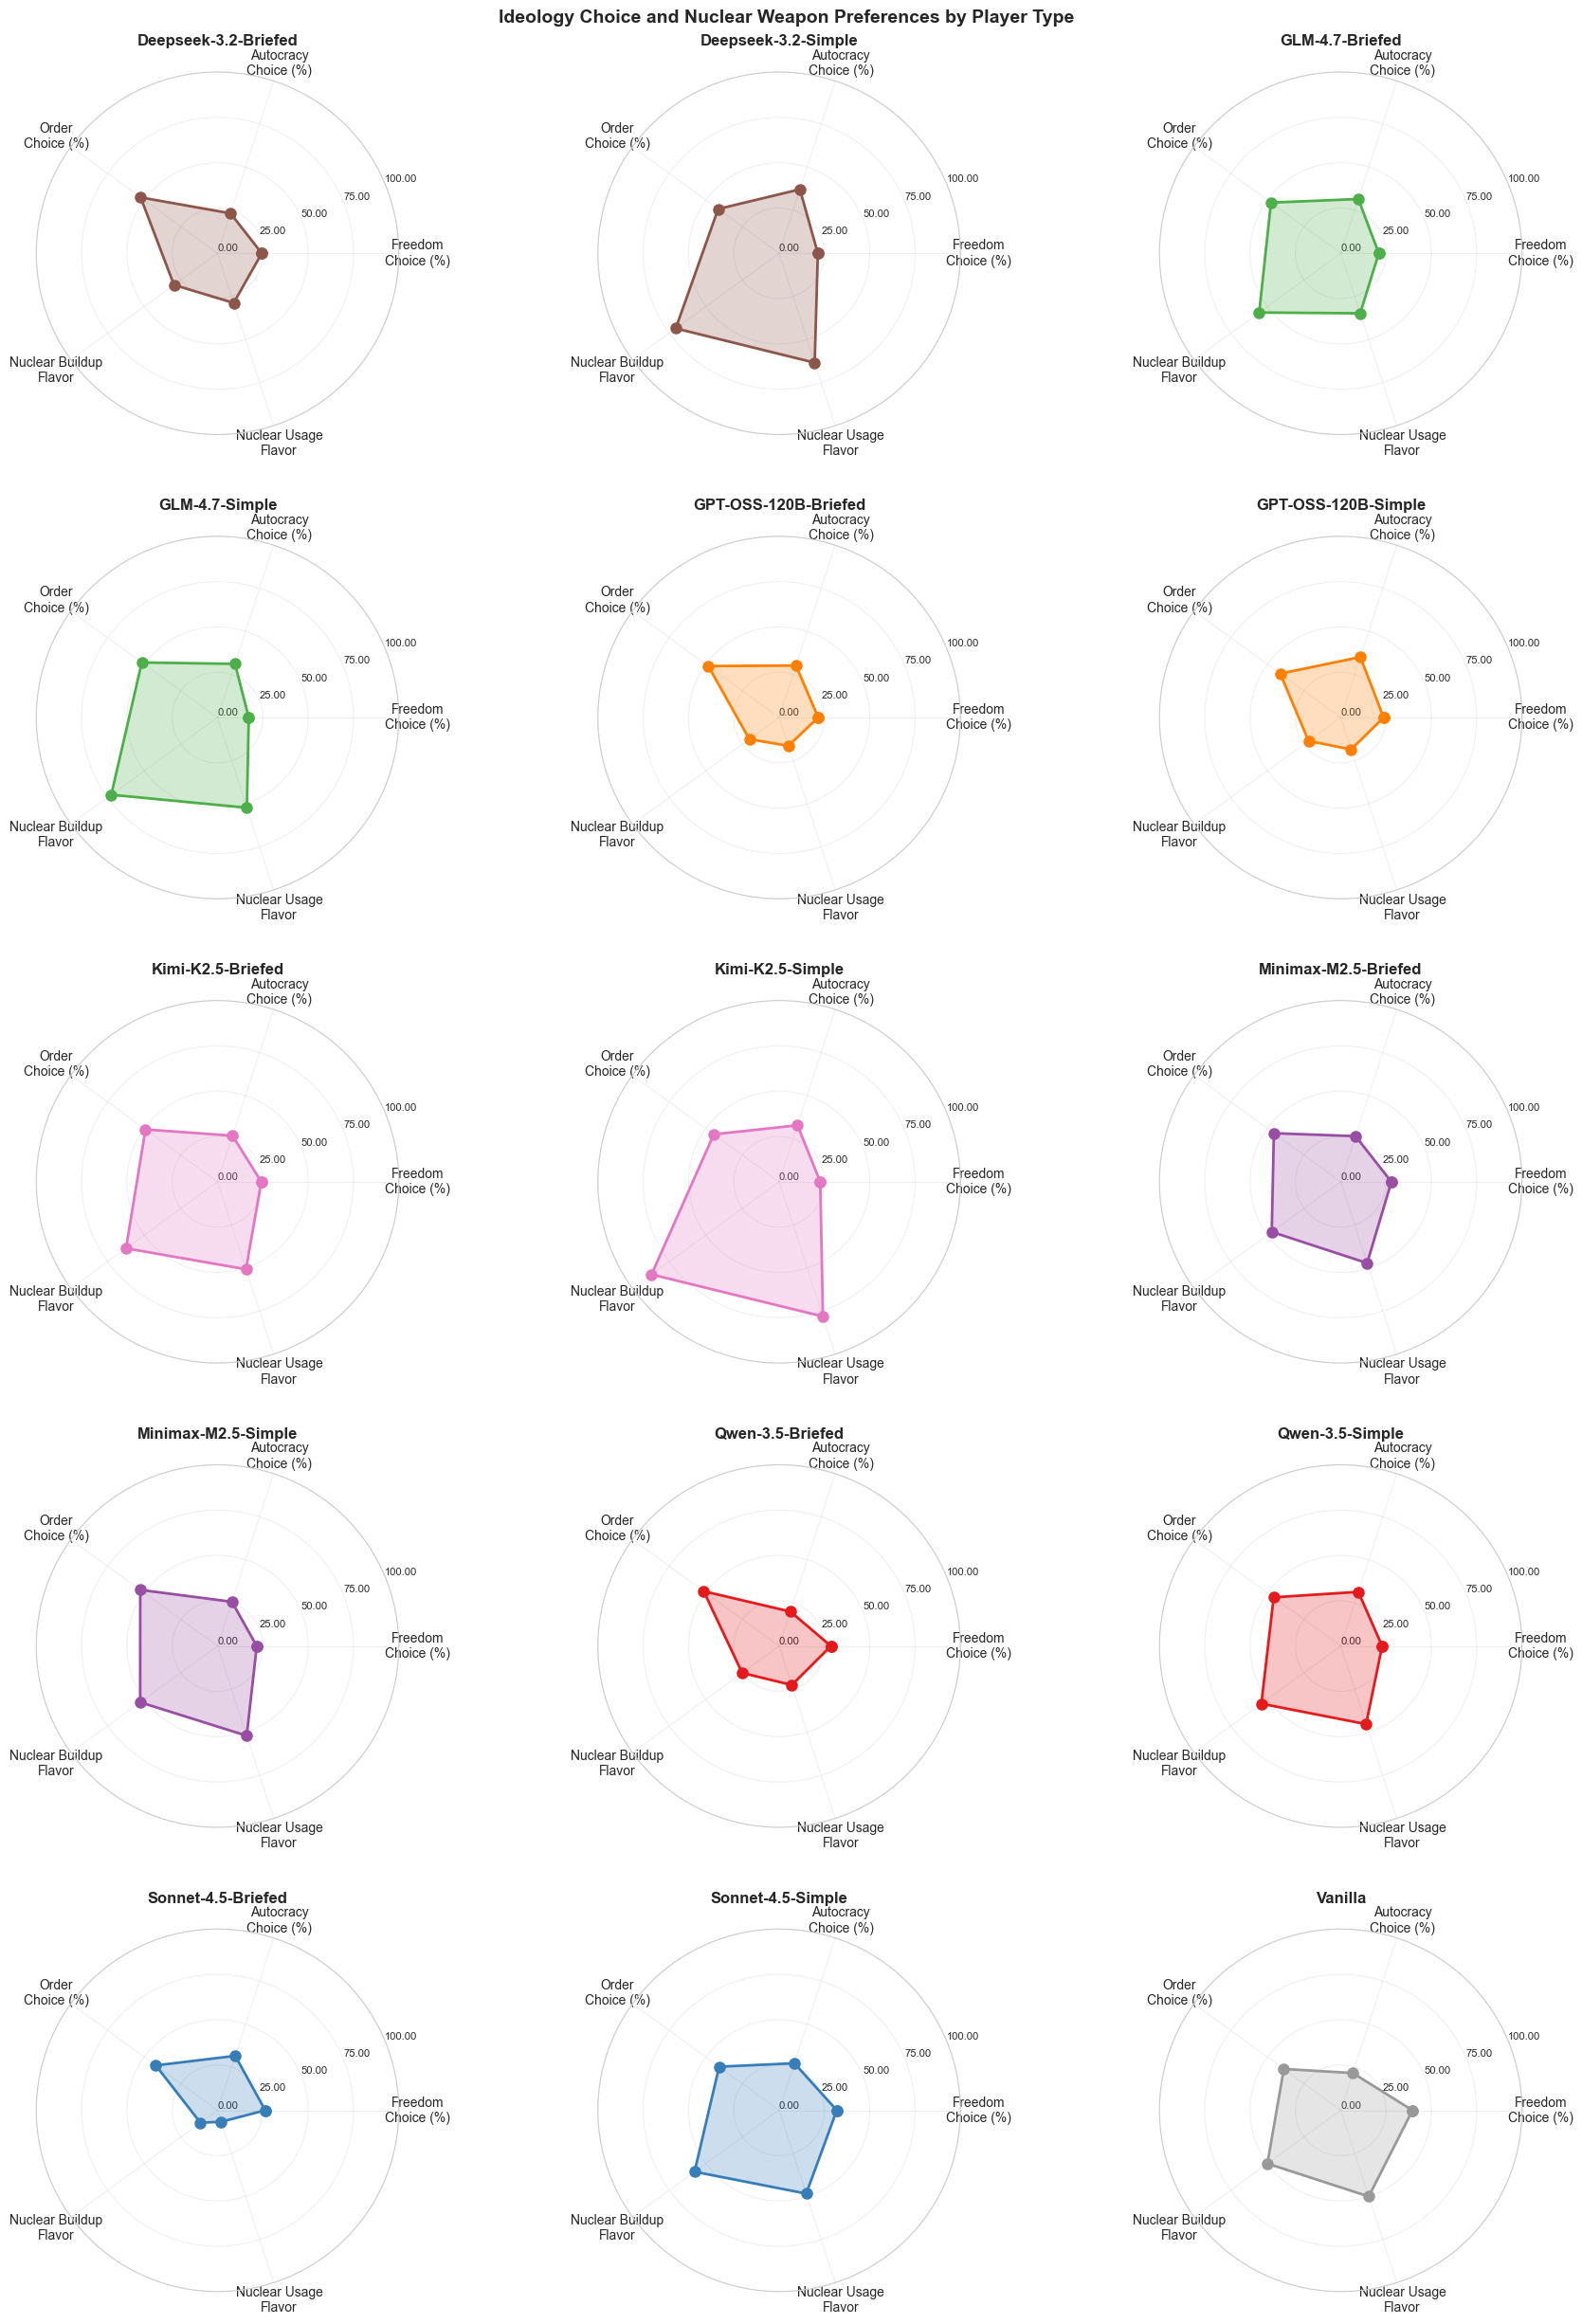


Ideology Choice and Nuclear Weapon Preferences by Player Type Summary:


c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\John Chen\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,N,Freedom Choice (%),Autocracy Choice (%),Order Choice (%),Nuclear Buildup Flavor,Nuclear Usage Flavor
Deepseek-3.2-Briefed,116,"24.390 [14.896, 33.884]","23.171 [13.843, 32.498]","52.439 [41.398, 63.480]","29.697 [19.997, 39.397]","28.788 [19.302, 38.274]"
Deepseek-3.2-Simple,116,"21.348 [12.668, 30.029]","37.079 [26.846, 47.311]","41.573 [31.132, 52.014]","70.513 [58.092, 82.934]","63.462 [50.510, 76.413]"
GLM-4.7-Briefed,180,"20.979 [14.225, 27.733]","31.469 [23.765, 39.172]","47.552 [39.268, 55.837]","55.609 [48.393, 62.824]","34.826 [28.684, 40.968]"
GLM-4.7-Simple,180,"17.219 [11.128, 23.309]","31.126 [23.656, 38.596]","51.656 [43.593, 59.718]","72.473 [66.340, 78.606]","52.333 [46.536, 58.130]"
GPT-OSS-120B-Briefed,153,"21.552 [13.957, 29.147]","30.172 [21.694, 38.651]","48.276 [39.046, 57.506]","20.317 [15.986, 24.649]","16.429 [12.765, 20.092]"
GPT-OSS-120B-Simple,153,"23.684 [15.761, 31.608]","35.088 [26.193, 43.982]","41.228 [32.054, 50.402]","21.940 [15.861, 28.020]","18.507 [13.272, 23.742]"
Kimi-K2.5-Briefed,144,"24.138 [16.234, 32.042]","26.724 [18.550, 34.898]","49.138 [39.904, 58.372]","62.431 [55.081, 69.780]","50.764 [44.020, 57.508]"
Kimi-K2.5-Simple,144,"22.689 [15.054, 30.324]","32.773 [24.216, 41.330]","44.538 [35.477, 53.598]","86.985 [81.609, 92.362]","78.132 [71.001, 85.264]"
Minimax-M2.5-Briefed,91,"27.941 [16.999, 38.883]","26.471 [15.712, 37.229]","45.588 [33.443, 57.733]","47.027 [43.997, 50.057]","47.162 [43.423, 50.901]"
Minimax-M2.5-Simple,91,"21.622 [12.019, 31.224]","25.676 [15.486, 35.866]","52.703 [41.057, 64.349]","52.778 [48.588, 56.968]","52.037 [47.505, 56.569]"


(<Figure size 1800x2500 with 15 Axes>,
 array([<PolarAxes: title={'center': 'Deepseek-3.2-Briefed'}>,
        <PolarAxes: title={'center': 'Deepseek-3.2-Simple'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Briefed'}>,
        <PolarAxes: title={'center': 'GLM-4.7-Simple'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Briefed'}>,
        <PolarAxes: title={'center': 'GPT-OSS-120B-Simple'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Kimi-K2.5-Simple'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Briefed'}>,
        <PolarAxes: title={'center': 'Minimax-M2.5-Simple'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Briefed'}>,
        <PolarAxes: title={'center': 'Qwen-3.5-Simple'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Briefed'}>,
        <PolarAxes: title={'center': 'Sonnet-4.5-Simple'}>,
        <PolarAxes: title={'center': 'Vanilla'}>], dtype=object))

In [14]:
# Choice of ideology (first adopted among freedom/autocracy/order)
ideology_cols = ['freedom', 'autocracy', 'order']
panel_df['ideology_choice'] = (
    panel_df[ideology_cols]
    .idxmin(axis=1)
    .where(panel_df[ideology_cols].notna().any(axis=1), None)
    .str.title()
)

# Create binary columns for each ideology choice (0-100 scale to match nuclear flavors)
# Only set values for games where an ideology was actually adopted
panel_df['freedom_pct'] = None
panel_df['autocracy_pct'] = None
panel_df['order_pct'] = None

# Only calculate for games with ideology choice
ideology_mask = panel_df['ideology_choice'].notna()
panel_df.loc[ideology_mask, 'freedom_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Freedom').astype(float) * 100
panel_df.loc[ideology_mask, 'autocracy_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Autocracy').astype(float) * 100
panel_df.loc[ideology_mask, 'order_pct'] = (panel_df.loc[ideology_mask, 'ideology_choice'] == 'Order').astype(float) * 100

# Create radar chart showing ideology choices and nuclear flavors by player type
plot_strategy_radar_charts(
    panel_df,
    columns=['freedom_pct', 'autocracy_pct', 'order_pct', 'nuke', 'use_nuke'],
    labels=['Freedom\nChoice (%)', 'Autocracy\nChoice (%)', 'Order\nChoice (%)', 
            'Nuclear Buildup\nFlavor', 'Nuclear Usage\nFlavor'],
    title='Ideology Choice and Nuclear Weapon Preferences by Player Type',
    ylim=(0, 100),
    print_summary=True
)

## 4. Survival Rate (Survival Turns / Game Length)

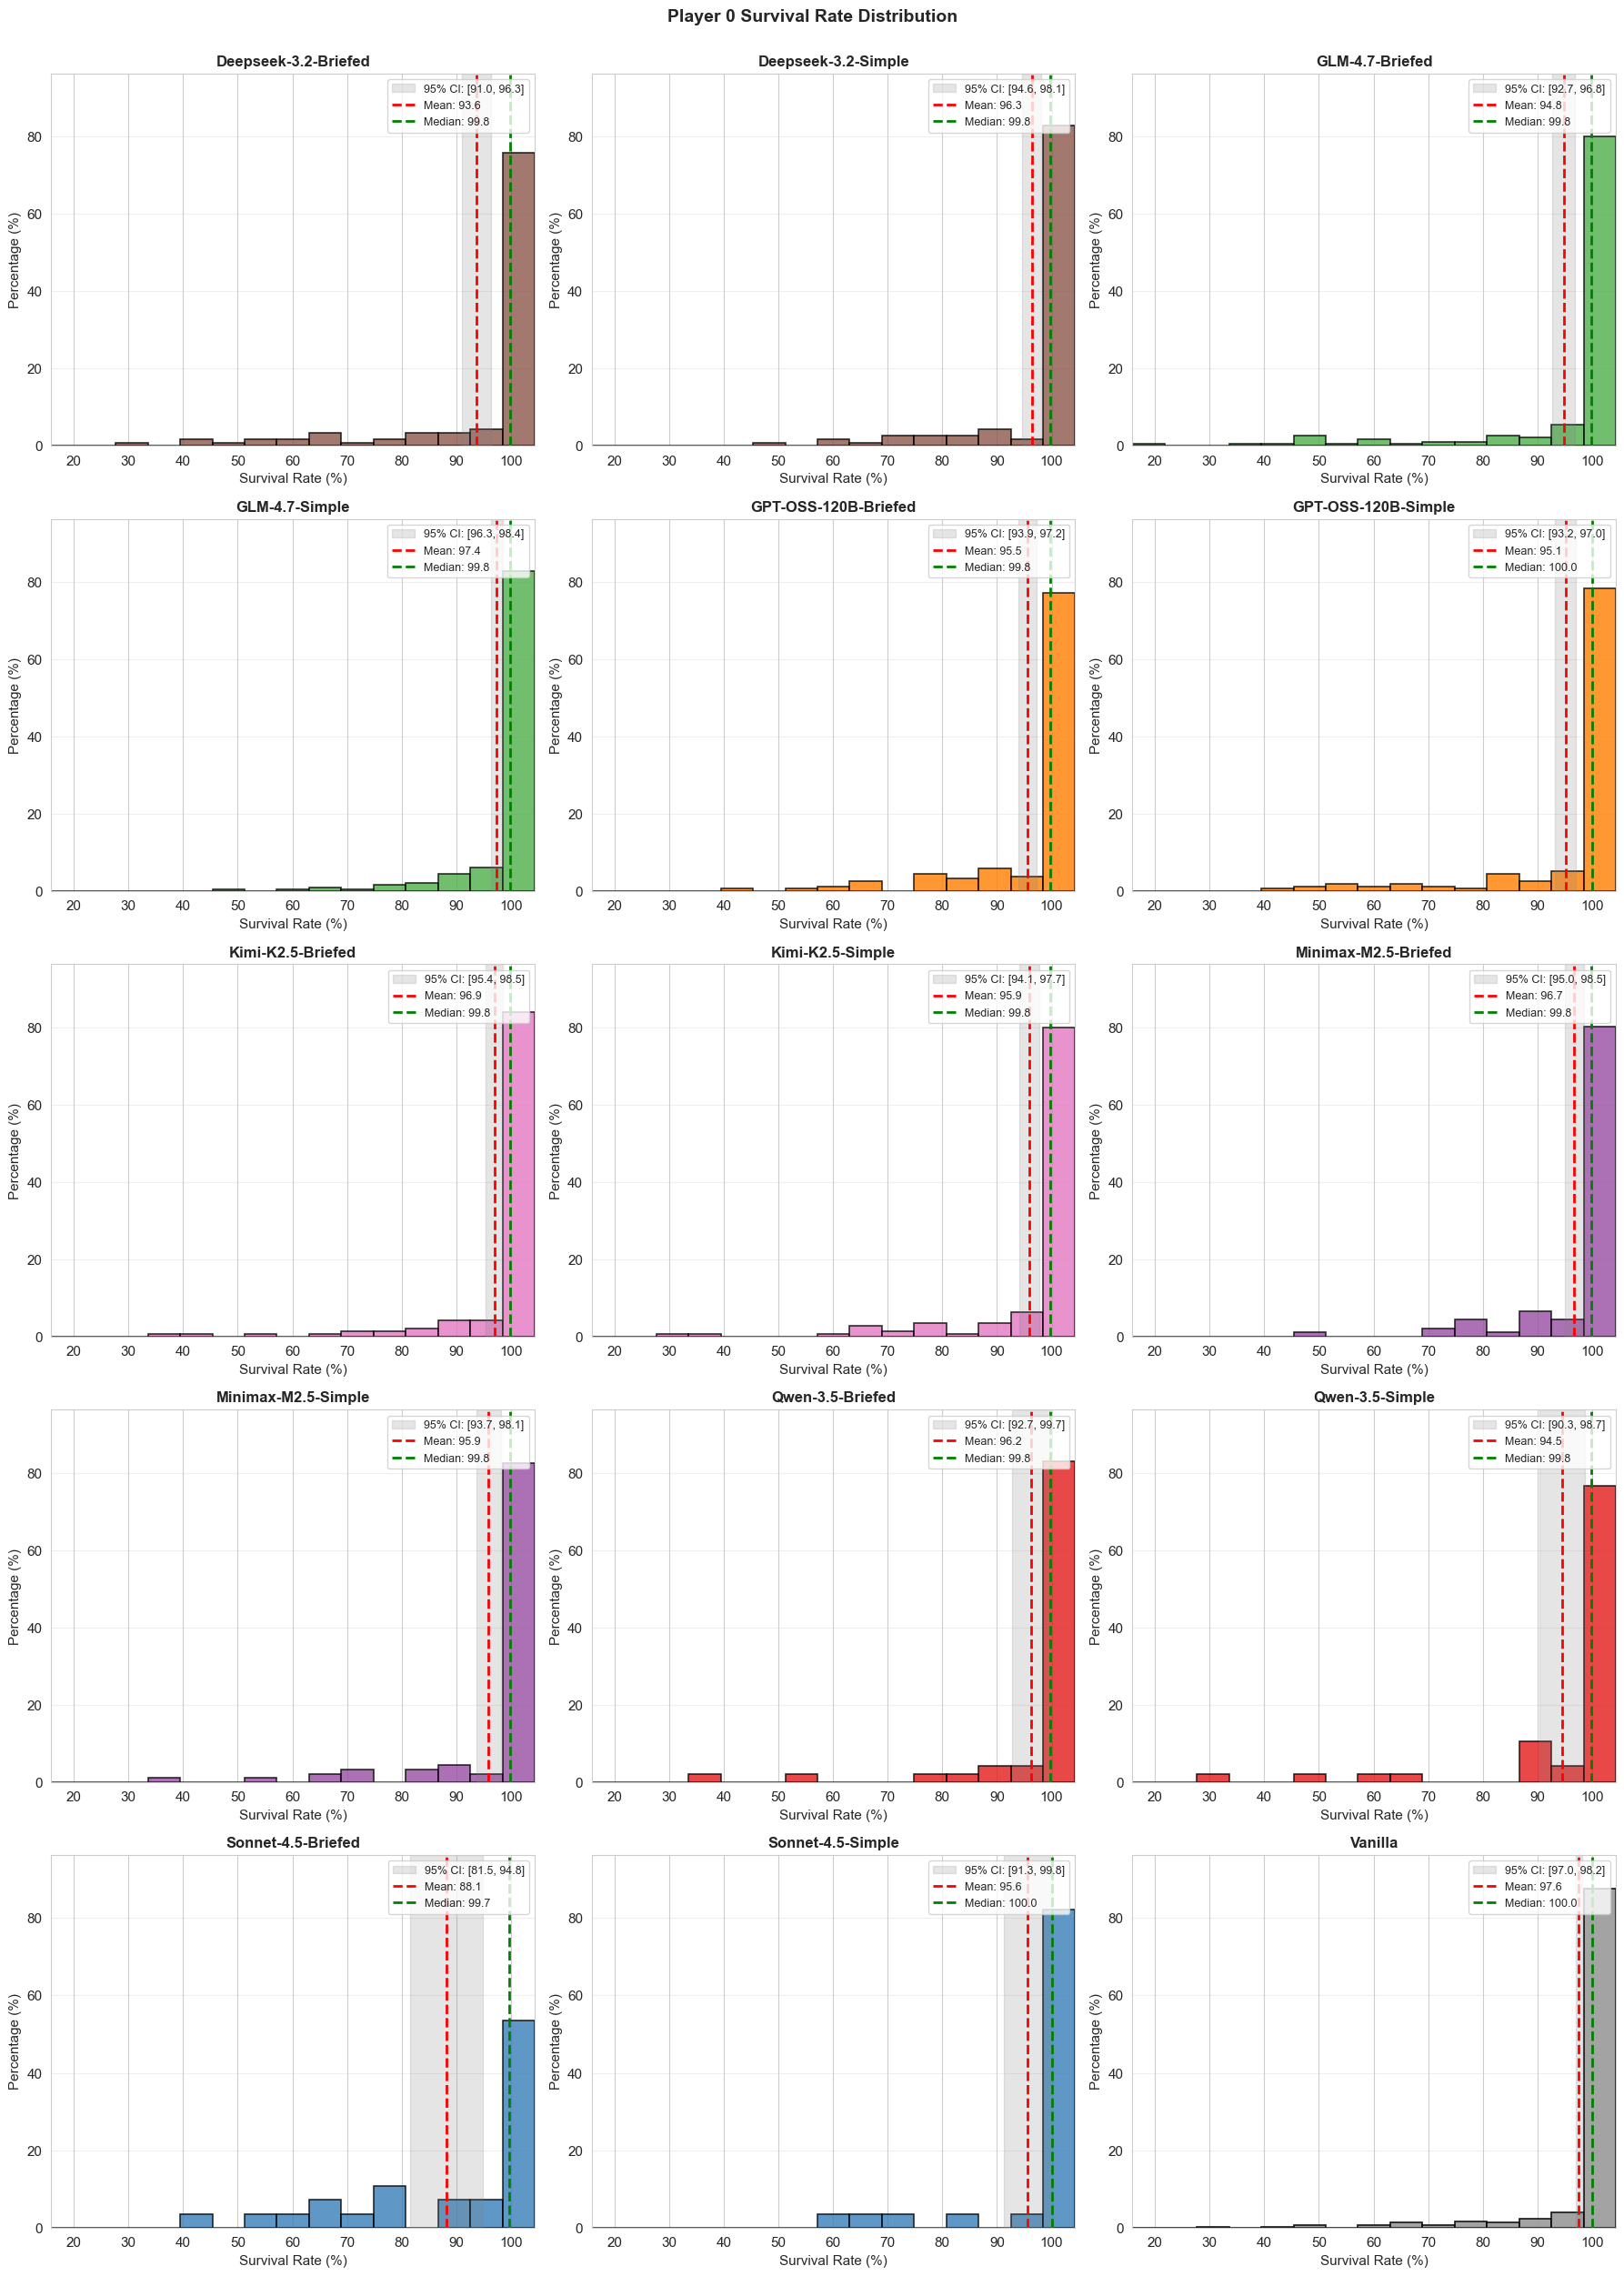


Player 0 Survival Rate Distribution Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Deepseek-3.2-Briefed,116,93.61,99.77,14.45,33.2,100.0,"[90.96, 96.27]"
Deepseek-3.2-Simple,116,96.34,99.79,9.41,48.5,100.0,"[94.61, 98.07]"
GLM-4.7-Briefed,180,94.78,99.78,14.00,19.9,100.0,"[92.72, 96.84]"
GLM-4.7-Simple,180,97.37,99.78,7.27,48.4,100.3,"[96.30, 98.43]"
GPT-OSS-120B-Briefed,153,95.53,99.80,10.28,42.2,100.3,"[93.88, 97.17]"
GPT-OSS-120B-Simple,153,95.11,100.00,12.03,43.7,100.3,"[93.19, 97.03]"
Kimi-K2.5-Briefed,144,96.92,99.78,9.41,39.0,100.0,"[95.37, 98.47]"
Kimi-K2.5-Simple,144,95.88,99.78,11.09,29.8,100.0,"[94.06, 97.71]"
Minimax-M2.5-Briefed,91,96.74,99.78,8.31,47.2,100.0,"[95.01, 98.47]"
Minimax-M2.5-Simple,91,95.88,99.78,10.70,38.9,100.0,"[93.65, 98.11]"


In [15]:
# Calculate survival rate (survival turns / game length)
panel_df['survival_rate'] = panel_df['survival_turn'] / panel_df['turn'] * 100

# Use the reusable function for distribution histograms
plot_distribution_histograms(
    panel_df,
    'survival_rate',
    'Survival Rate (%)',
    'Player 0 Survival Rate Distribution'
)

## 5. Highest Ranking by Condition

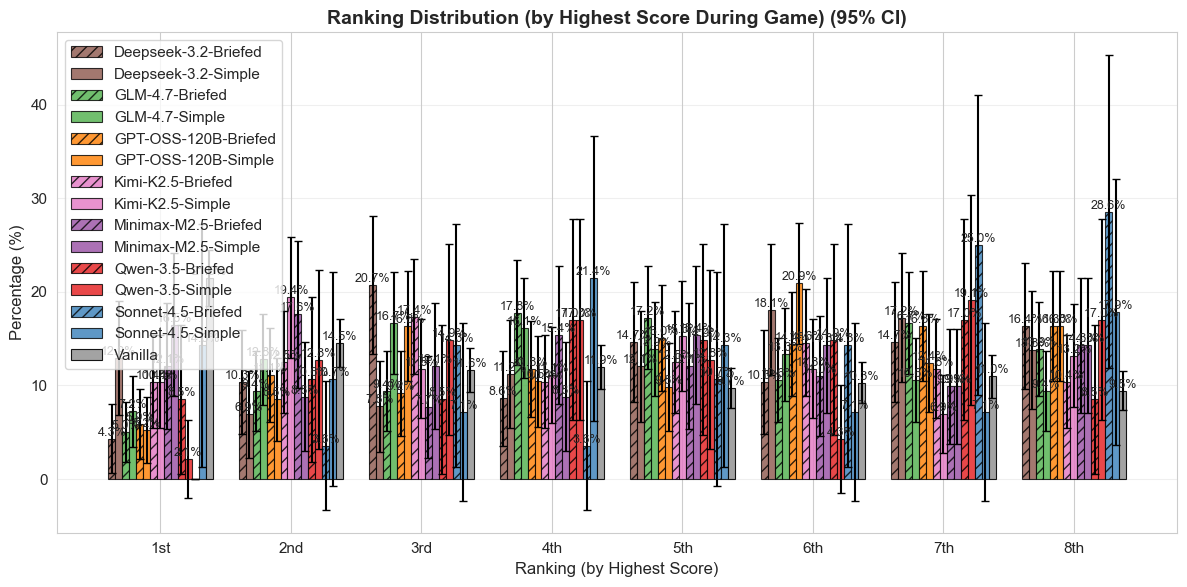

,1st,2nd,3rd,4th,5th,6th,7th,8th
Deepseek-3.2-Briefed,5 (4.3%),12 (10.3%),24 (20.7%),10 (8.6%),17 (14.7%),12 (10.3%),17 (14.7%),19 (16.4%)
Deepseek-3.2-Simple,15 (12.9%),8 (6.9%),9 (7.8%),13 (11.2%),14 (12.1%),21 (18.1%),20 (17.2%),16 (13.8%)
GLM-4.7-Briefed,9 (5.0%),17 (9.4%),17 (9.4%),32 (17.8%),31 (17.2%),19 (10.6%),30 (16.7%),25 (13.9%)
GLM-4.7-Simple,13 (7.2%),23 (12.8%),30 (16.7%),29 (16.1%),25 (13.9%),24 (13.3%),19 (10.6%),17 (9.4%)
GPT-OSS-120B-Briefed,9 (5.9%),17 (11.1%),14 (9.2%),18 (11.8%),23 (15.0%),22 (14.4%),25 (16.3%),25 (16.3%)
GPT-OSS-120B-Simple,8 (5.2%),13 (8.5%),25 (16.3%),16 (10.5%),15 (9.8%),32 (20.9%),19 (12.4%),25 (16.3%)
Kimi-K2.5-Briefed,15 (10.4%),18 (12.5%),25 (17.4%),15 (10.4%),18 (12.5%),21 (14.6%),17 (11.8%),15 (10.4%)
Kimi-K2.5-Simple,15 (10.4%),28 (19.4%),17 (11.8%),16 (11.1%),22 (15.3%),17 (11.8%),10 (6.9%),19 (13.2%)
Minimax-M2.5-Briefed,11 (12.1%),16 (17.6%),7 (7.7%),14 (15.4%),11 (12.1%),10 (11.0%),9 (9.9%),13 (14.3%)
Minimax-M2.5-Simple,15 (16.5%),8 (8.8%),11 (12.1%),8 (8.8%),14 (15.4%),13 (14.3%),9 (9.9%),13 (14.3%)


In [16]:
# Player 0 ranking distribution (based on highest score during game)
plot_grouped_bar_chart(
    panel_df,
    value_col=None,  # Not used when use_percentage=True
    category_col='score_rank',
    xlabel='Ranking (by Highest Score)',
    ylabel='Percentage (%)',
    title='Ranking Distribution (by Highest Score During Game)',
    use_percentage=True,
    show_error_bars=True,
    x_labels=['1st', '2nd', '3rd', '4th', '5th', '6th', '7th', '8th']
)

## 6. Score Ratio Distribution

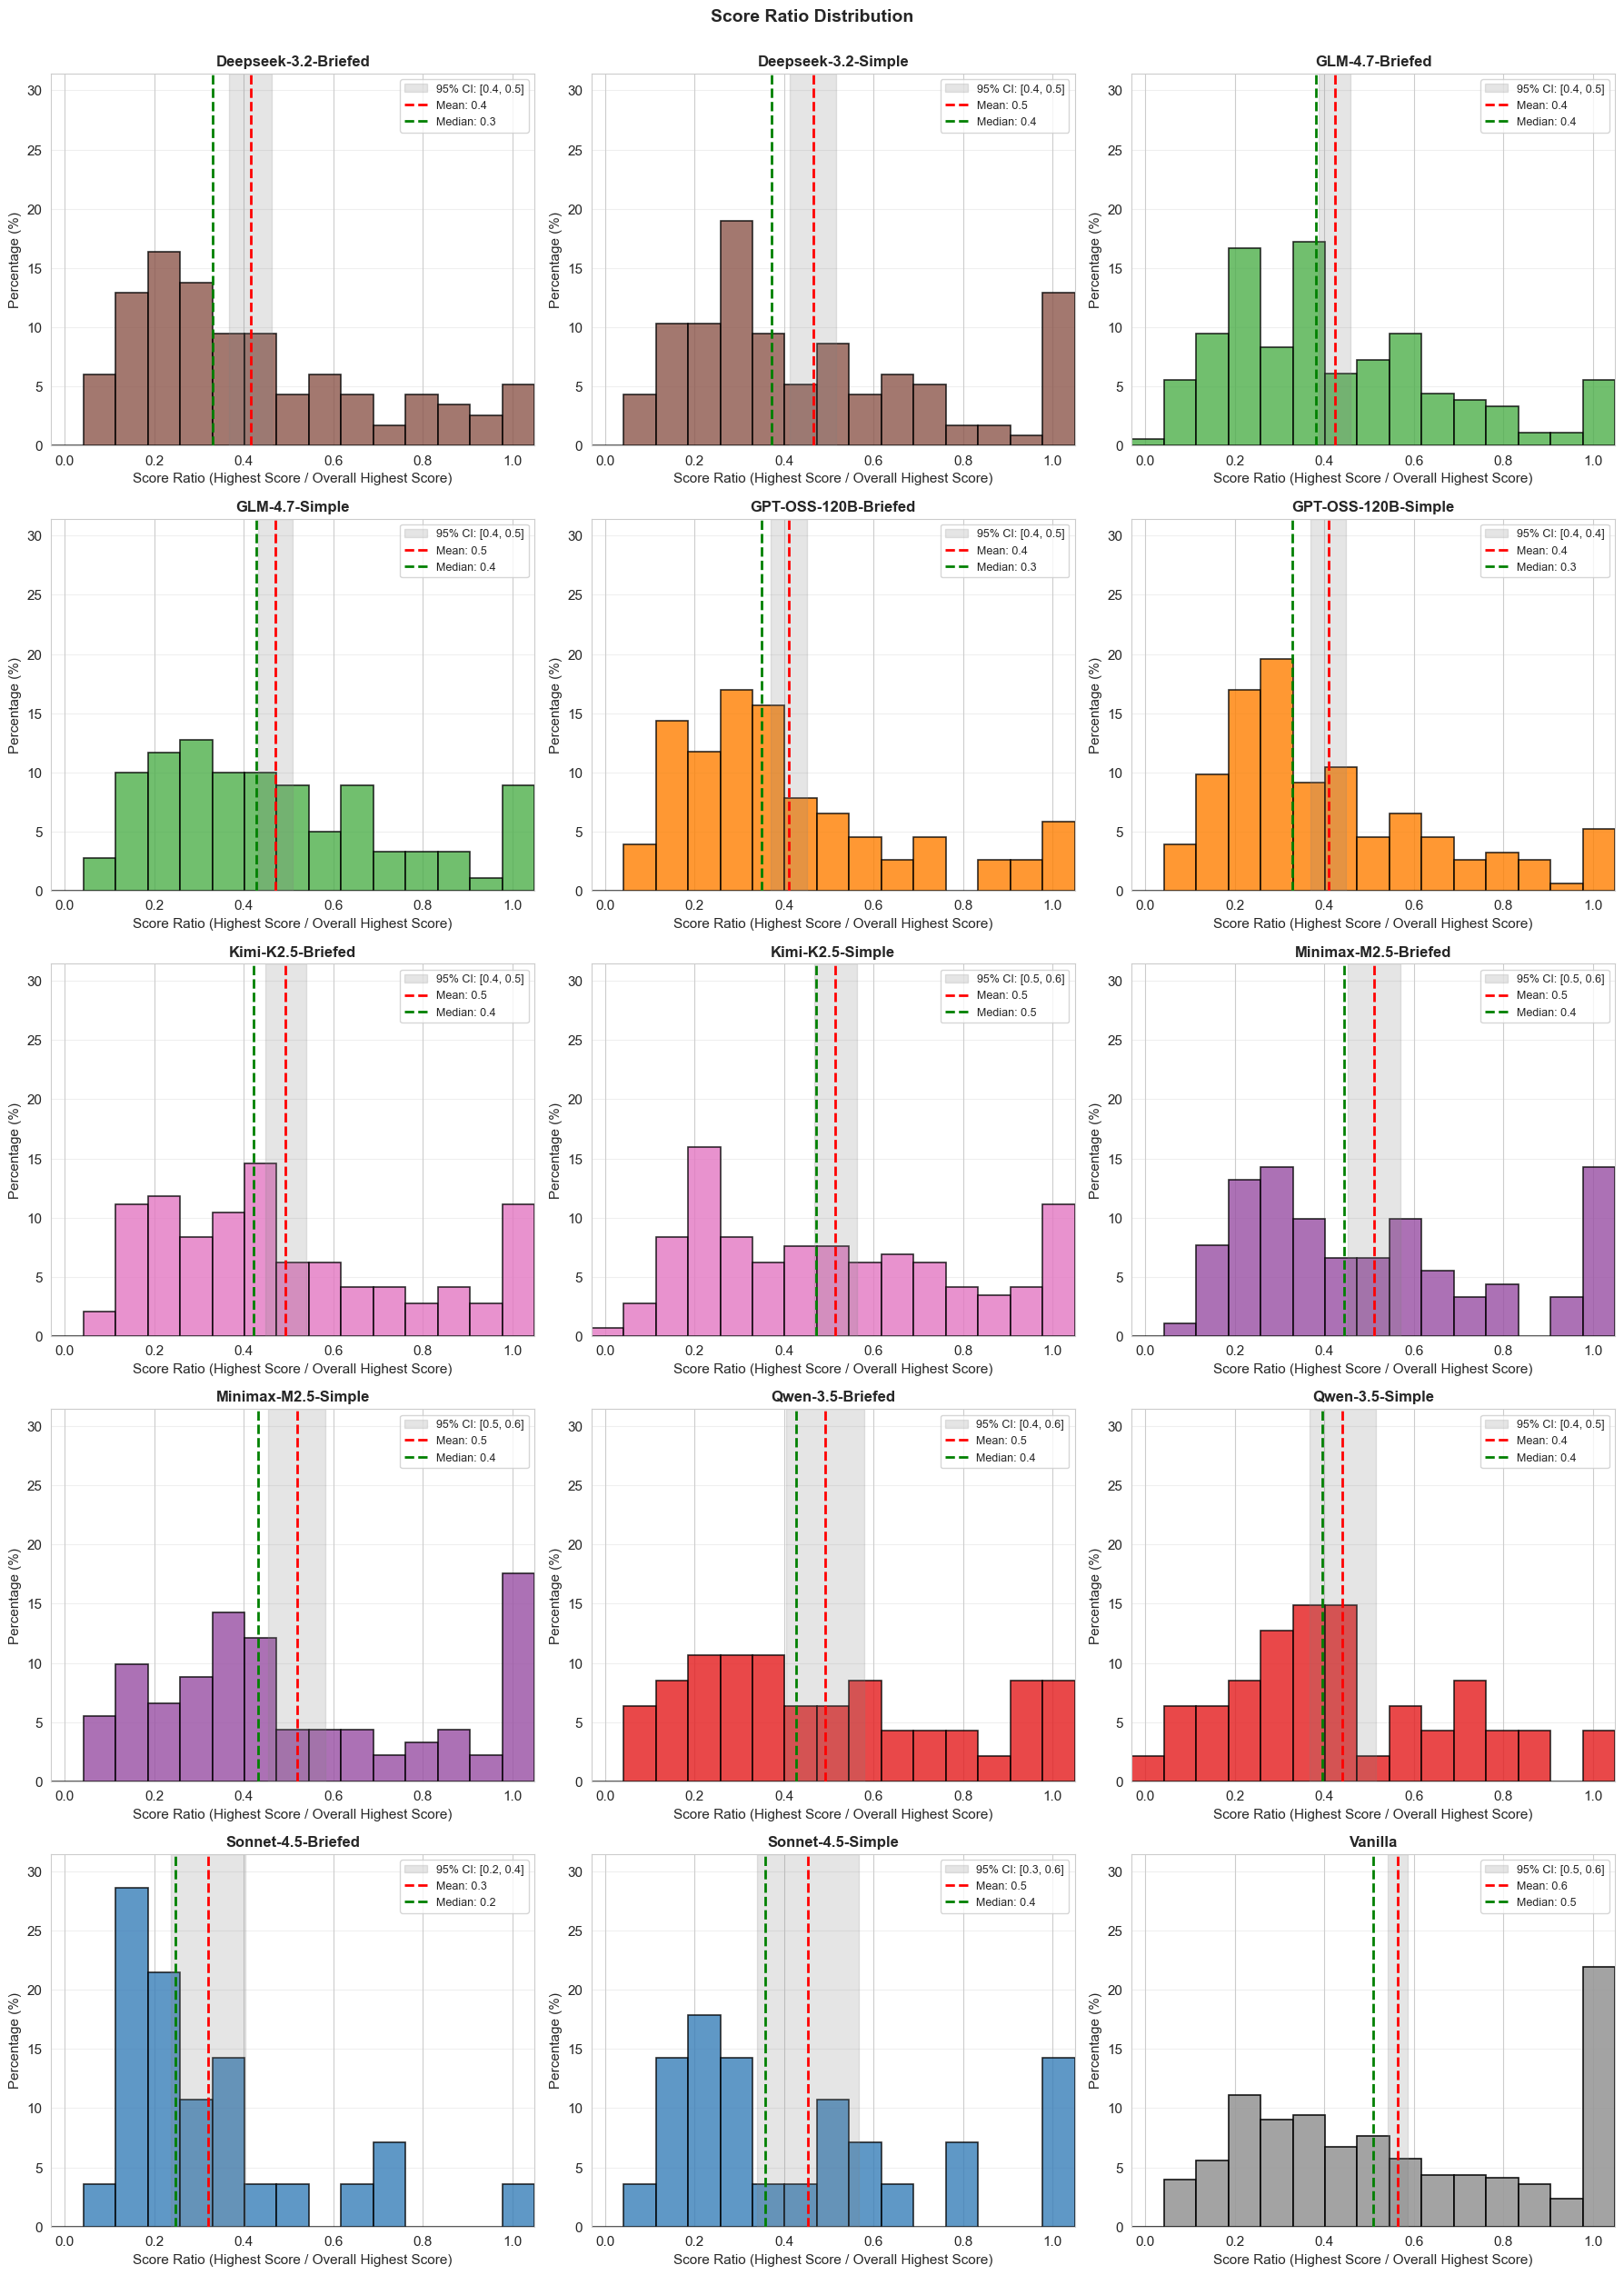


Score Ratio Distribution Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Deepseek-3.2-Briefed,116,0.41,0.33,0.26,0.0,1.0,"[0.37, 0.46]"
Deepseek-3.2-Simple,116,0.46,0.37,0.28,0.1,1.0,"[0.41, 0.52]"
GLM-4.7-Briefed,180,0.42,0.38,0.25,0.0,1.0,"[0.39, 0.46]"
GLM-4.7-Simple,180,0.47,0.43,0.26,0.1,1.0,"[0.43, 0.51]"
GPT-OSS-120B-Briefed,153,0.41,0.35,0.25,0.1,1.0,"[0.37, 0.45]"
GPT-OSS-120B-Simple,153,0.41,0.33,0.24,0.1,1.0,"[0.37, 0.45]"
Kimi-K2.5-Briefed,144,0.49,0.42,0.28,0.1,1.0,"[0.45, 0.54]"
Kimi-K2.5-Simple,144,0.52,0.47,0.29,0.0,1.0,"[0.47, 0.56]"
Minimax-M2.5-Briefed,91,0.51,0.44,0.28,0.1,1.0,"[0.45, 0.57]"
Minimax-M2.5-Simple,91,0.52,0.43,0.31,0.1,1.0,"[0.45, 0.58]"


In [17]:
# Player 0 Score Ratio Distribution
plot_distribution_histograms(
    panel_df, 
    'score_ratio',
    'Score Ratio (Highest Score / Overall Highest Score)',
    'Score Ratio Distribution'
)

## 7. Nuke Behavior: Use-Nuke and Nuke Inclination

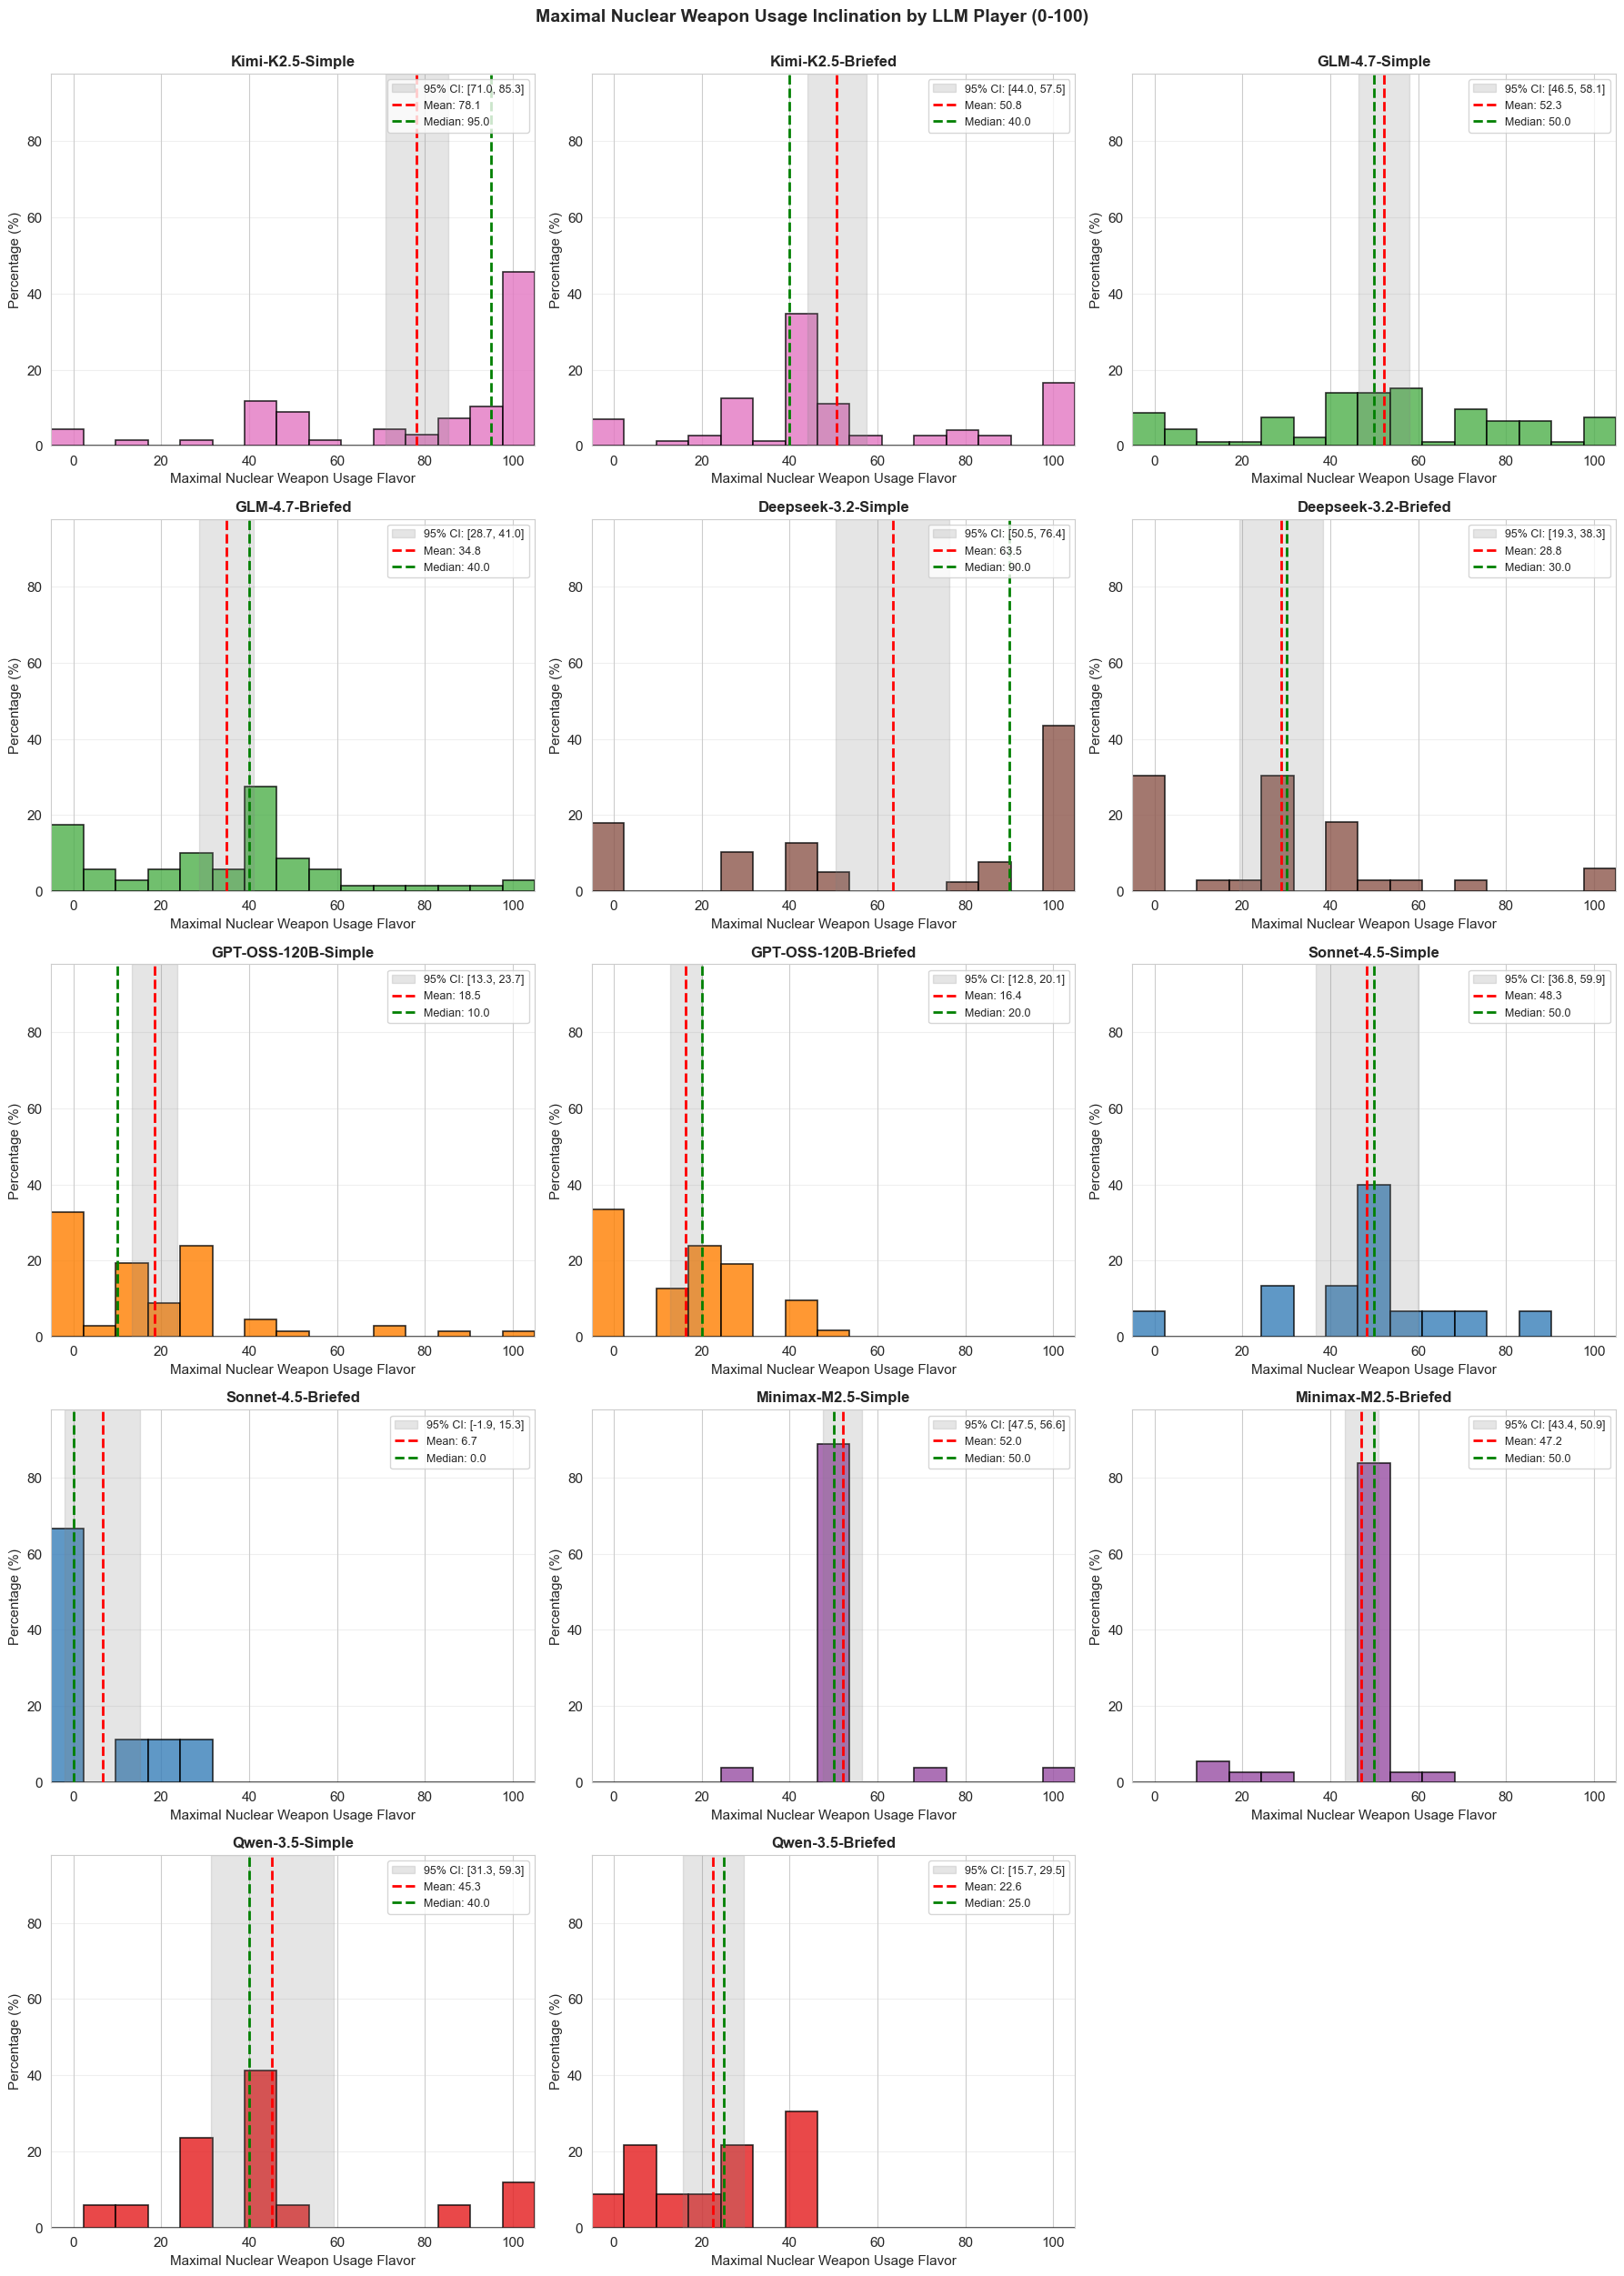


Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100) Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Kimi-K2.5-Simple,68,78.13,95.0,29.46,0.0,100.0,"[71.00, 85.26]"
Kimi-K2.5-Briefed,72,50.76,40.0,28.70,0.0,100.0,"[44.02, 57.51]"
GLM-4.7-Simple,93,52.33,50.0,28.15,0.0,100.0,"[46.54, 58.13]"
GLM-4.7-Briefed,69,34.83,40.0,25.57,0.0,100.0,"[28.68, 40.97]"
Deepseek-3.2-Simple,39,63.46,90.0,39.95,0.0,100.0,"[50.51, 76.41]"
Deepseek-3.2-Briefed,33,28.79,30.0,26.75,0.0,100.0,"[19.30, 38.27]"
GPT-OSS-120B-Simple,67,18.51,10.0,21.46,0.0,100.0,"[13.27, 23.74]"
GPT-OSS-120B-Briefed,63,16.43,20.0,14.55,0.0,50.0,"[12.76, 20.09]"
Sonnet-4.5-Simple,15,48.33,50.0,20.85,0.0,90.0,"[36.79, 59.88]"
Sonnet-4.5-Briefed,9,6.67,0.0,11.18,0.0,30.0,"[-1.93, 15.26]"


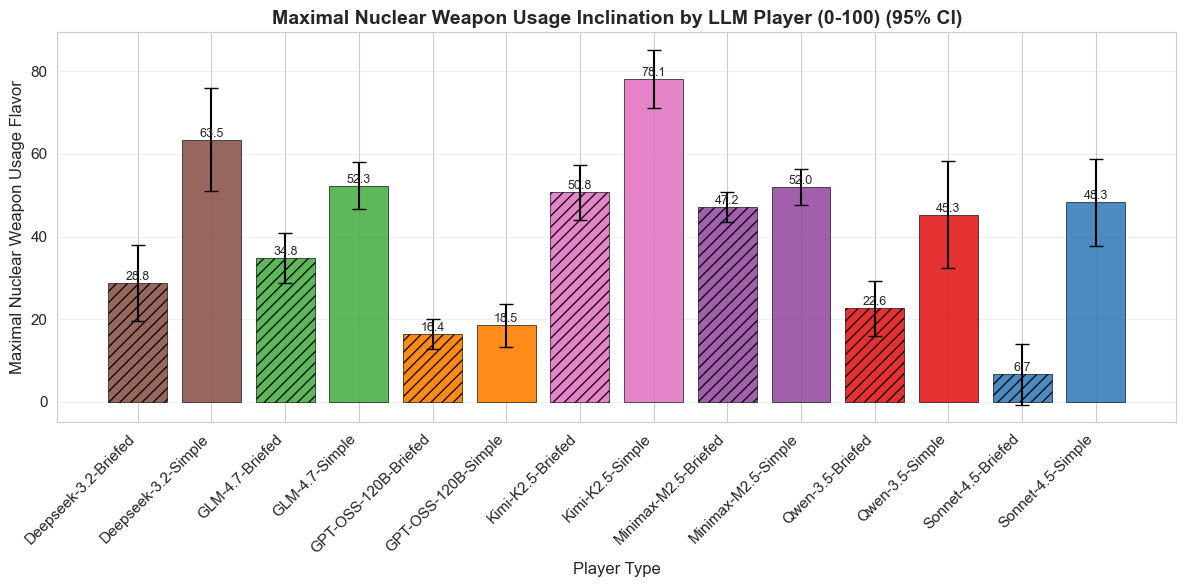

,Mean,Std,N
Deepseek-3.2-Briefed,28.787879,26.752053,33
Deepseek-3.2-Simple,63.461538,39.953161,39
GLM-4.7-Briefed,34.826087,25.567648,69
GLM-4.7-Simple,52.333333,28.147258,93
GPT-OSS-120B-Briefed,16.428571,14.547713,63
GPT-OSS-120B-Simple,18.507463,21.461998,67
Kimi-K2.5-Briefed,50.763889,28.700244,72
Kimi-K2.5-Simple,78.132353,29.463311,68
Minimax-M2.5-Briefed,47.162162,11.213864,37
Minimax-M2.5-Simple,52.037037,11.457216,27


In [19]:
# Filter to LLM players only (exclude Vanilla)
llm_players = [pt for pt in panel_df['player_type'].unique() if pt != 'Vanilla']

plot_distribution_histograms(
    panel_df,
    'use_nuke',
    'Maximal Nuclear Weapon Usage Flavor',
    'Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100)',
    player_type_filter=llm_players
)

# Bar chart version with model-based colors
plot_bar_chart(
    panel_df[panel_df['player_type'].isin(llm_players)],
    value_col='use_nuke',
    category_col='player_type',
    xlabel='Player Type',
    ylabel='Maximal Nuclear Weapon Usage Flavor',
    title='Maximal Nuclear Weapon Usage Inclination by LLM Player (0-100)',
    figsize=(12,6),
    use_percentage=False,
    show_error_bars=True,
    color_by_category=True
)

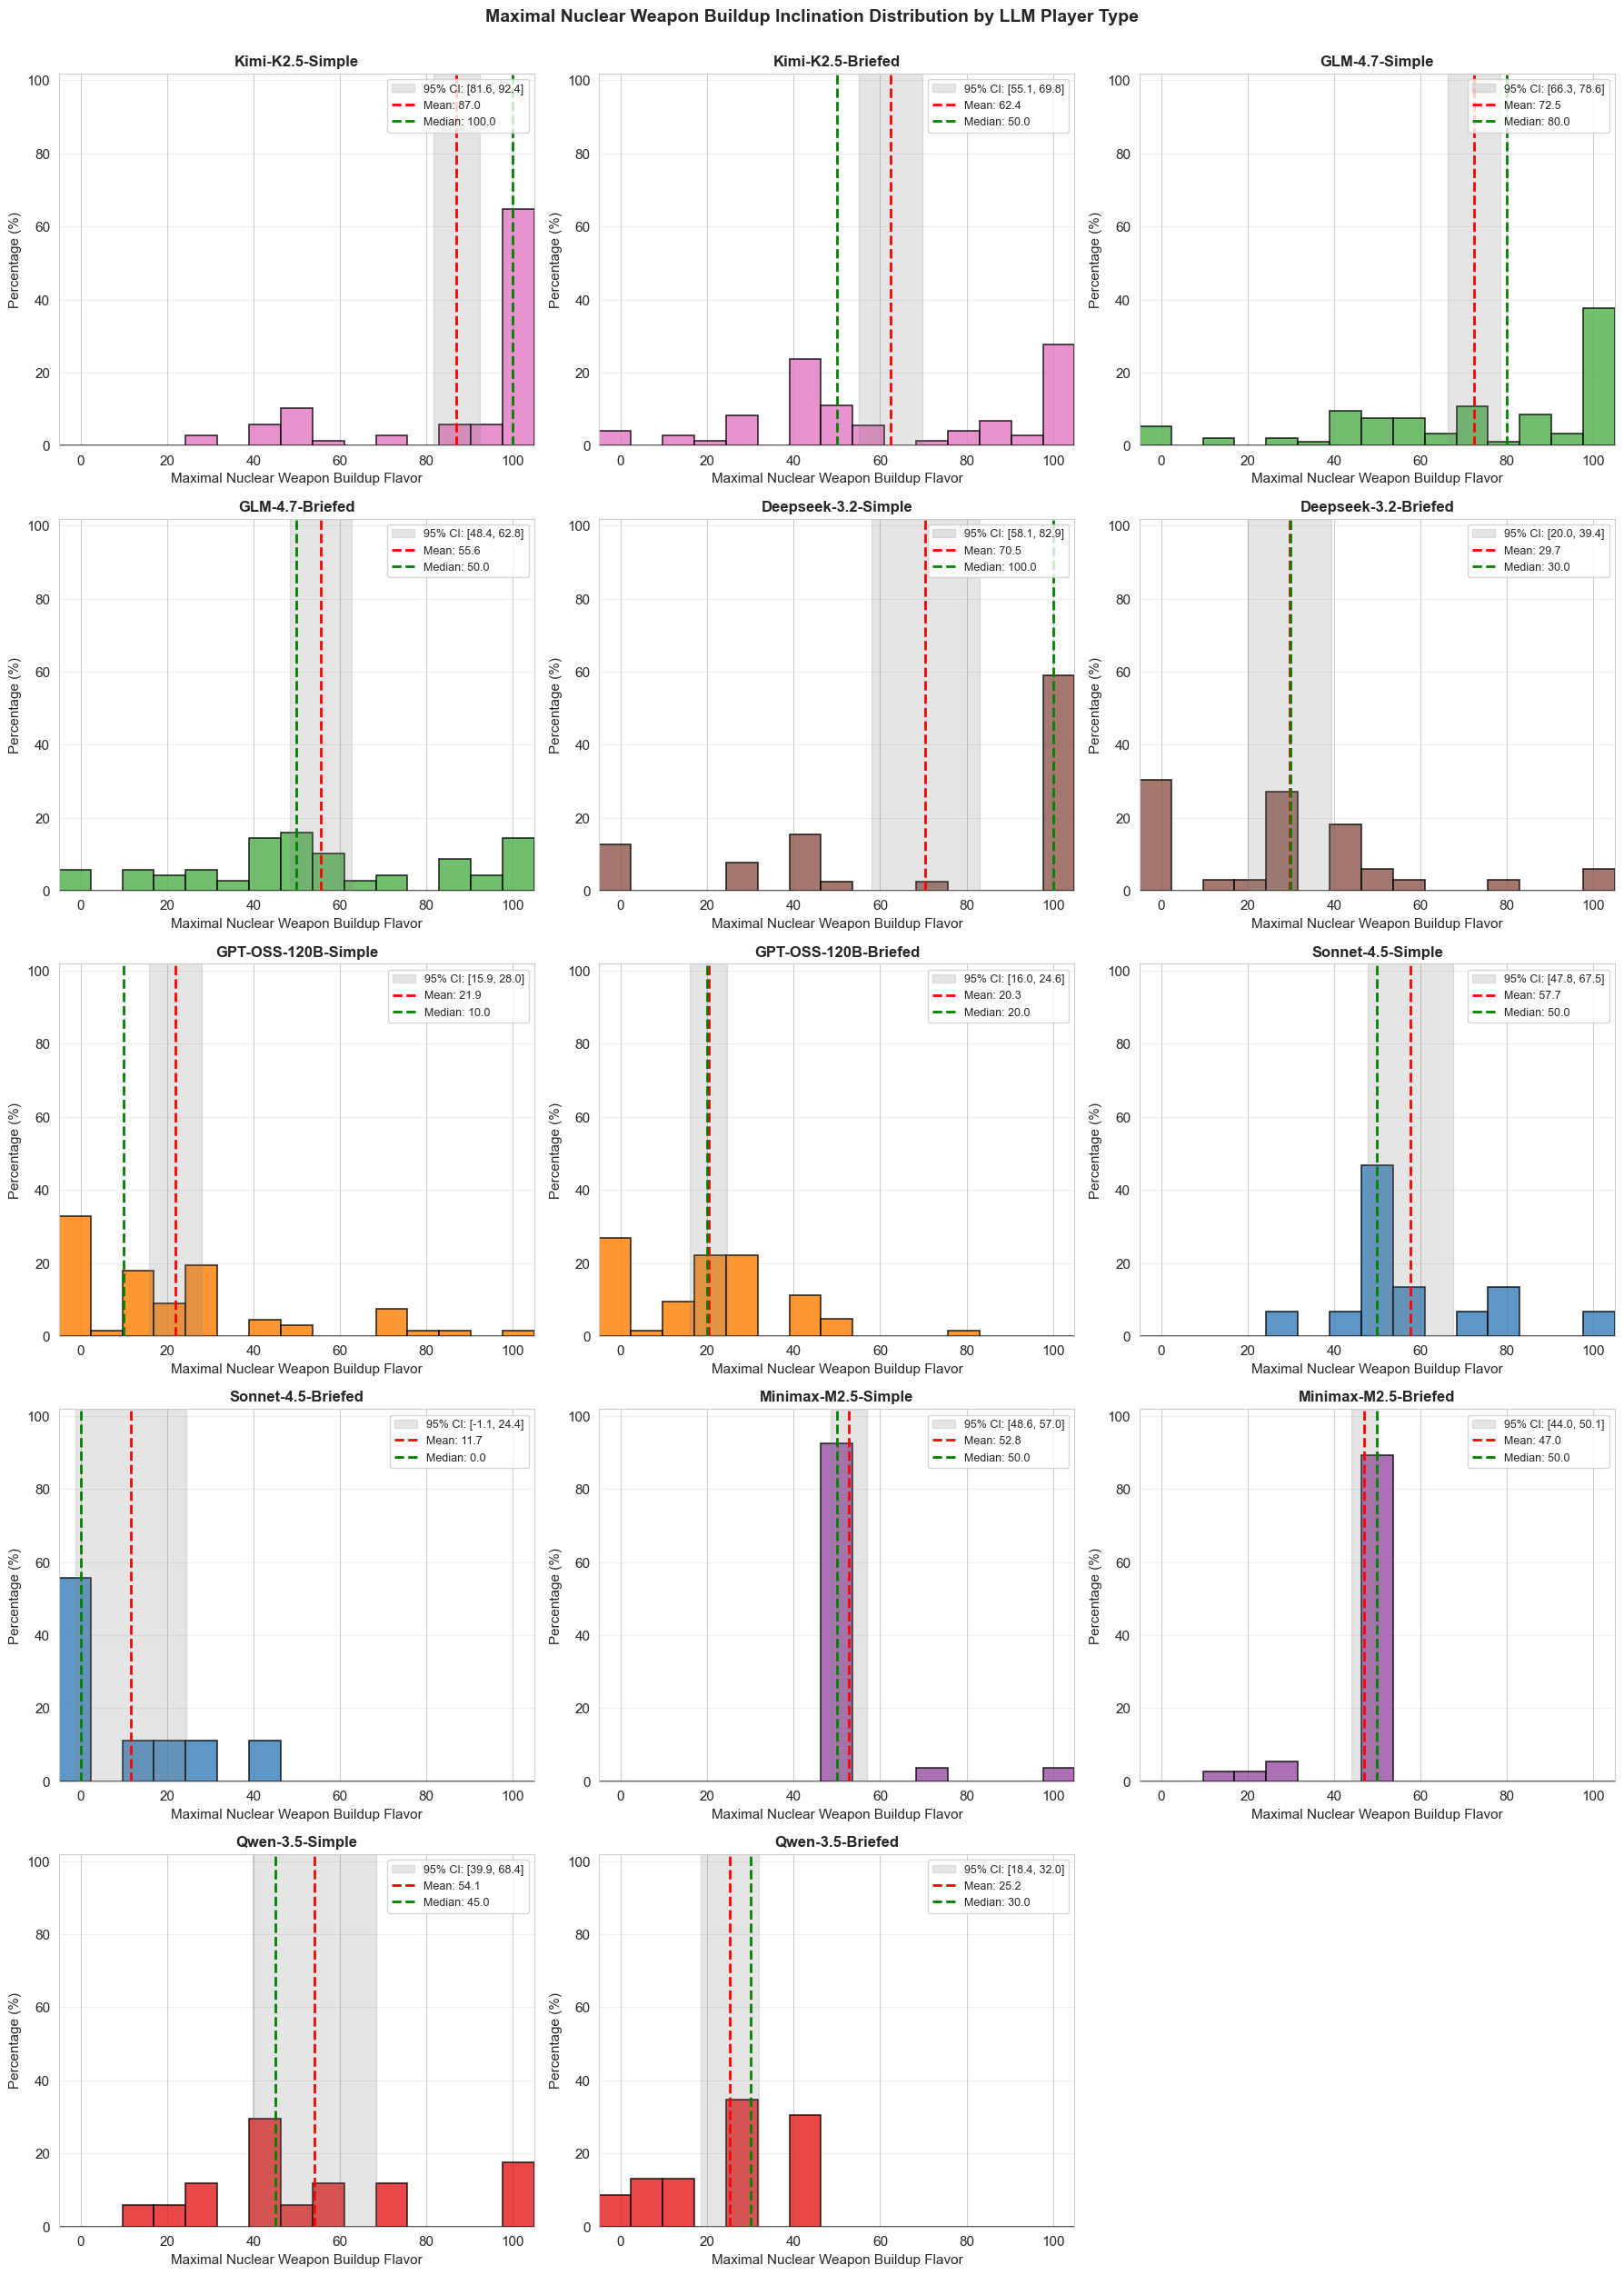


Maximal Nuclear Weapon Buildup Inclination Distribution by LLM Player Type Statistics:


,N,Mean,Median,Std,Min,Max,95% CI
Kimi-K2.5-Simple,68,86.99,100.0,22.21,30.0,100.0,"[81.61, 92.36]"
Kimi-K2.5-Briefed,72,62.43,50.0,31.28,0.0,100.0,"[55.08, 69.78]"
GLM-4.7-Simple,93,72.47,80.0,29.78,0.0,100.0,"[66.34, 78.61]"
GLM-4.7-Briefed,69,55.61,50.0,30.04,0.0,100.0,"[48.39, 62.82]"
Deepseek-3.2-Simple,39,70.51,100.0,38.32,0.0,100.0,"[58.09, 82.93]"
Deepseek-3.2-Briefed,33,29.70,30.0,27.36,0.0,100.0,"[20.00, 39.40]"
GPT-OSS-120B-Simple,67,21.94,10.0,24.92,0.0,100.0,"[15.86, 28.02]"
GPT-OSS-120B-Briefed,63,20.32,20.0,17.20,0.0,80.0,"[15.99, 24.65]"
Sonnet-4.5-Simple,15,57.67,50.0,17.82,30.0,100.0,"[47.80, 67.53]"
Sonnet-4.5-Briefed,9,11.67,0.0,16.58,0.0,45.0,"[-1.08, 24.41]"


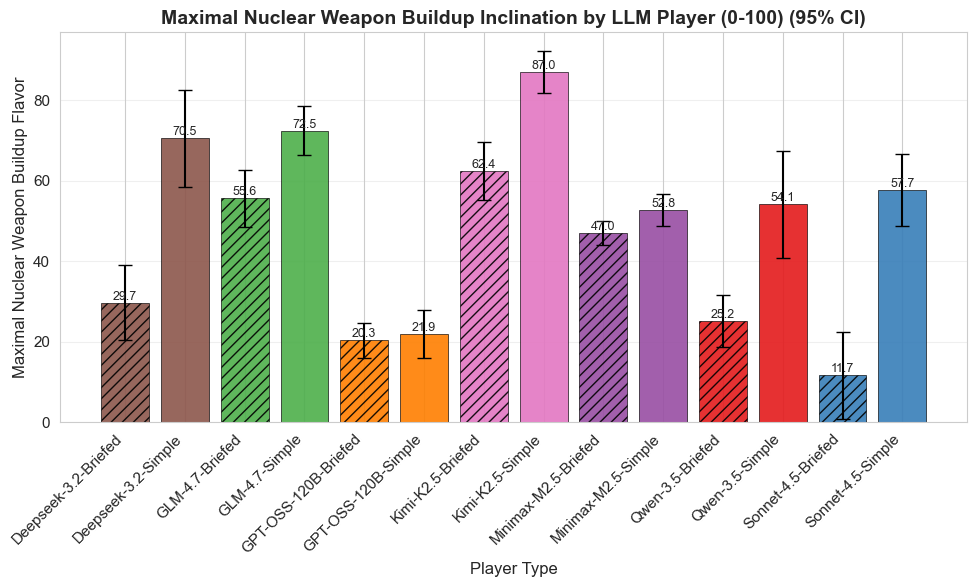

,Mean,Std,N
Deepseek-3.2-Briefed,29.696970,27.355855,33
Deepseek-3.2-Simple,70.512821,38.316461,39
GLM-4.7-Briefed,55.608696,30.036359,69
GLM-4.7-Simple,72.473118,29.778381,93
GPT-OSS-120B-Briefed,20.317460,17.200736,63
GPT-OSS-120B-Simple,21.940299,24.923447,67
Kimi-K2.5-Briefed,62.430556,31.275615,72
Kimi-K2.5-Simple,86.985294,22.212335,68
Minimax-M2.5-Briefed,47.027027,9.087496,37
Minimax-M2.5-Simple,52.777778,10.591482,27


In [20]:
plot_distribution_histograms(
    panel_df,
    'nuke',
    'Maximal Nuclear Weapon Buildup Flavor',
    'Maximal Nuclear Weapon Buildup Inclination Distribution by LLM Player Type',
    player_type_filter=llm_players
)

# Bar chart version with model-based colors
plot_bar_chart(
    panel_df[panel_df['player_type'].isin(llm_players)],
    value_col='nuke',
    category_col='player_type',
    xlabel='Player Type',
    ylabel='Maximal Nuclear Weapon Buildup Flavor',
    title='Maximal Nuclear Weapon Buildup Inclination by LLM Player (0-100)',
    use_percentage=False,
    show_error_bars=True,
    color_by_category=True
)